# Supplemental Material

This file contains the supplemental materials for *Title of paper*. It includes all supplemental figures and tables. Additional materials are made available on our study’s OSF page (<https://osf.io/zh5gn/>).

------------------------------------------------------------------------

In [ ]:
#| label: set up

library(dplyr) |> suppressMessages()
library(skimr)

In [ ]:
#| label: read in data

d_0 <- data.table::fread(here::here(rdrive_path, "batch_results_new_method_0.csv"))
d_05 <- data.table::fread(here::here(rdrive_path, "batch_results_new_method_05.csv"))

d_20_covs <- data.table::fread(here::here(rdrive_path, "batch_results_20_covs.csv"))
d_n50 <- data.table::fread(here::here(rdrive_path, "batch_results_n50.csv"))

d2_0 <- data.table::fread(here::here(rdrive_path, "batch_results_new_20K_0.csv"))
d2_05 <- data.table::fread(here::here(rdrive_path, "batch_results_new_20K_05.csv"))

d_wo_x_0 <- data.table::fread(here::here(rdrive_path, "batch_results_methods_wo_x_seed0.csv"))
d_wo_x_1 <- data.table::fread(here::here(rdrive_path, "batch_results_methods_wo_x_seed1.csv"))

d_02_0 <- data.table::fread(here::here(rdrive_path, "batch_results_02_seed0.csv"))
d_02_1 <- data.table::fread(here::here(rdrive_path, "batch_results_02_seed1.csv"))

In [ ]:
#| label: combine data

d_0 <- rbind(d_0, d_20_covs |> filter(b_x == 0))
d_0 <- rbind(d_0, d_n50 |> filter(b_x == 0))

d_05 <- rbind(d_05, d_20_covs |> filter(b_x == 0.5))
d_05 <- rbind(d_05, d_n50 |> filter(b_x == 0.5))

rm(d_20_covs, d_n50)

d_0 <- rbind(d_0, d2_0)
d_05 <- rbind(d_05, d2_05)

rm(d2_0, d2_05)

d_0 <- rbind(d_0, d_wo_x_0 |> filter(b_x == 0))
d_0 <- rbind(d_0, d_wo_x_1 |> filter(b_x == 0))

d_05 <- rbind(d_05, d_wo_x_0 |> filter(b_x == 0.5))
d_05 <- rbind(d_05, d_wo_x_1 |> filter(b_x == 0.5))

rm(d_wo_x_0, d_wo_x_1)

d_02 <- rbind(d_02_0, d_02_1)

rm(d_02_0, d_02_1)

In [ ]:
#| label: factor levels

d_0 <- d_0 |> 
  mutate(method = factor(method, levels = c("no_covs", "all_covs","p_hacked",  "r",
                                            "partial_r", "full_lm_wo_x", "full_lm",  
                                           "lasso_wo_x", "lasso"),
                         labels = c("No covariates", "All covariates", "p-hacking", 
                                    "Single covariate lm", "Single covariate lm with X", 
                                    "All covariates lm", "All covariates lm with X", 
                                            "All covariates LASSO", "All covariates LASSO with X")))

d_02 <- d_02 |> 
  mutate(method = factor(method, levels = c("no_covs", "all_covs","p_hacked",   "r", 
                                            "partial_r", "full_lm_wo_x", "full_lm",  
                                           "lasso_wo_x", "lasso"),
                         labels = c( "No covariates", "All covariates", "p-hacking", 
                                    "Single covariate lm", "Single covariate lm with X", 
                                    "All covariates lm", "All covariates lm with X", 
                                            "All covariates LASSO", "All covariates LASSO with X")))

d_05 <- d_05 |> 
  mutate(method = factor(method, levels = c("no_covs", "all_covs","p_hacked",   "r", 
                                            "partial_r", "full_lm_wo_x", "full_lm",  
                                           "lasso_wo_x", "lasso"),
                         labels = c("No covariates", "All covariates", "p-hacking", 
                                    "Single covariate lm", "Single covariate lm with X", 
                                    "All covariates lm", "All covariates lm with X", 
                                            "All covariates LASSO", "All covariates LASSO with X")))

### Type I error

In [ ]:
#| label: histogram variable 0

h0 <- d_0 |> 
  group_by(method, n_obs, n_covs, r_ycov, p_good_covs, r_cov) |> 
  summarise(type_I = mean(p_value < 0.05),
            .groups = "drop")

In [ ]:
#| label: tbl-typeI-nobs 

d_0 |> 
  group_by(method, n_obs, n_covs, r_ycov, p_good_covs, r_cov) |> 
  summarise(prop_sig = mean(p_value < 0.05),
            .groups = "drop") |> 
  group_by(n_obs, method) |> 
  summarise(typeI_min = min(prop_sig),
            typeI_max = max(prop_sig),
            typeI_mean = mean(prop_sig),
            .groups = "drop") |> 
  kbl(caption = "Type I error by n_obs")

Warning in attr(x, "align"): 'xfun::attr()' is deprecated.
Use 'xfun::attr2()' instead.
See help("Deprecated")

    n_obs method                          typeI_min   typeI_max   typeI_mean
  ------- ----------------------------- ----------- ----------- ------------
       50 No covariates                       0.048       0.053        0.050
       50 All covariates                      0.048       0.052        0.050
       50 p-hacking                           0.084       0.426        0.215
       50 Single covariate lm                 0.047       0.052        0.050
       50 Single covariate lm with X          0.050       0.072        0.057
       50 All covariates lm                   0.048       0.052        0.050
       50 All covariates lm with X            0.054       0.096        0.074
       50 All covariates LASSO                0.048       0.052        0.050
       50 All covariates LASSO with X         0.052       0.089        0.069
      100 No covariates                       0.048       0.052        0.050
      100 All covariates                      0.048       0.053        0.050
      100 p-hacking                           0.078       0.449        0.203
      100 Single covariate lm                 0.048       0.053        0.050
      100 Single covariate lm with X          0.050       0.059        0.052
      100 All covariates lm                   0.047       0.054        0.050
      100 All covariates lm with X            0.051       0.087        0.064
      100 All covariates LASSO                0.048       0.052        0.050
      100 All covariates LASSO with X         0.051       0.067        0.058
      150 No covariates                       0.047       0.053        0.050
      150 All covariates                      0.047       0.052        0.050
      150 p-hacking                           0.076       0.454        0.198
      150 Single covariate lm                 0.048       0.051        0.050
      150 Single covariate lm with X          0.049       0.054        0.051
      150 All covariates lm                   0.047       0.052        0.050
      150 All covariates lm with X            0.049       0.081        0.059
      150 All covariates LASSO                0.047       0.052        0.050
      150 All covariates LASSO with X         0.049       0.062        0.055
      200 No covariates                       0.048       0.052        0.050
      200 All covariates                      0.048       0.053        0.050
      200 p-hacking                           0.074       0.456        0.194
      200 Single covariate lm                 0.047       0.053        0.050
      200 Single covariate lm with X          0.048       0.054        0.051
      200 All covariates lm                   0.048       0.052        0.050
      200 All covariates lm with X            0.048       0.071        0.056
      200 All covariates LASSO                0.048       0.052        0.050
      200 All covariates LASSO with X         0.049       0.059        0.054
      300 No covariates                       0.047       0.053        0.050
      300 All covariates                      0.048       0.053        0.050
      300 p-hacking                           0.073       0.455        0.189
      300 Single covariate lm                 0.048       0.053        0.050
      300 Single covariate lm with X          0.048       0.053        0.051
      300 All covariates lm                   0.049       0.052        0.050
      300 All covariates lm with X            0.049       0.061        0.054
      300 All covariates LASSO                0.048       0.052        0.050
      300 All covariates LASSO with X         0.049       0.056        0.052
      400 No covariates                       0.048       0.053        0.050
      400 All covariates                      0.047       0.052        0.050
      400 p-hacking                           0.071       0.462        0.186
      400 Single covariate lm                 0.047       0.052        0.050
      400 Single covariate lm with X          0.047       0.053        0.051
      400 All covariates lm                   0.047       0.052        0.050
      400 All covariates lm with X            0.047       0.058        0.053
      400 All covariates LASSO                0.047       0.052        0.050
      400 All covariates LASSO with X         0.047       0.055        0.052


In [ ]:
#| label: tbl-typeI-ncovs

d_0 |> 
  group_by(method, n_obs, n_covs, r_ycov, p_good_covs, r_cov) |> 
  summarise(prop_sig = mean(p_value < 0.05),
            .groups = "drop") |> 
  group_by(n_covs, method) |> 
  summarise(typeI_min = min(prop_sig),
            typeI_max = max(prop_sig),
            typeI_mean = mean(prop_sig),
            .groups = "drop") |> 
  kbl(caption = "Type I error by n_covs")

Warning in attr(x, "align"): 'xfun::attr()' is deprecated.
Use 'xfun::attr2()' instead.
See help("Deprecated")

    n_covs method                          typeI_min   typeI_max   typeI_mean
  -------- ----------------------------- ----------- ----------- ------------
         4 No covariates                       0.047       0.052        0.050
         4 All covariates                      0.047       0.053        0.050
         4 p-hacking                           0.071       0.140        0.098
         4 Single covariate lm                 0.047       0.053        0.050
         4 Single covariate lm with X          0.047       0.058        0.051
         4 All covariates lm                   0.048       0.052        0.050
         4 All covariates lm with X            0.047       0.062        0.053
         4 All covariates LASSO                0.048       0.052        0.050
         4 All covariates LASSO with X         0.047       0.058        0.052
         8 No covariates                       0.047       0.052        0.050
         8 All covariates                      0.048       0.053        0.050
         8 p-hacking                           0.094       0.238        0.150
         8 Single covariate lm                 0.047       0.052        0.050
         8 Single covariate lm with X          0.048       0.062        0.052
         8 All covariates lm                   0.047       0.054        0.050
         8 All covariates lm with X            0.048       0.082        0.056
         8 All covariates LASSO                0.047       0.052        0.050
         8 All covariates LASSO with X         0.049       0.067        0.054
        12 No covariates                       0.049       0.052        0.050
        12 All covariates                      0.047       0.052        0.050
        12 p-hacking                           0.117       0.329        0.201
        12 Single covariate lm                 0.047       0.052        0.050
        12 Single covariate lm with X          0.047       0.064        0.052
        12 All covariates lm                   0.047       0.052        0.050
        12 All covariates lm with X            0.047       0.093        0.060
        12 All covariates LASSO                0.047       0.052        0.050
        12 All covariates LASSO with X         0.048       0.074        0.057
        16 No covariates                       0.048       0.053        0.050
        16 All covariates                      0.048       0.053        0.050
        16 p-hacking                           0.139       0.404        0.249
        16 Single covariate lm                 0.047       0.053        0.050
        16 Single covariate lm with X          0.050       0.069        0.053
        16 All covariates lm                   0.047       0.052        0.050
        16 All covariates lm with X            0.051       0.094        0.064
        16 All covariates LASSO                0.048       0.052        0.050
        16 All covariates LASSO with X         0.051       0.080        0.059
        20 No covariates                       0.048       0.051        0.050
        20 All covariates                      0.047       0.052        0.050
        20 p-hacking                           0.165       0.462        0.290
        20 Single covariate lm                 0.048       0.052        0.050
        20 Single covariate lm with X          0.048       0.072        0.053
        20 All covariates lm                   0.048       0.052        0.050
        20 All covariates lm with X            0.050       0.096        0.066
        20 All covariates LASSO                0.047       0.052        0.050
        20 All covariates LASSO with X         0.050       0.089        0.061


In [ ]:
#| label: tbl-typeI-pgoodcovs

d_0 |> 
  group_by(method, n_obs, n_covs, r_ycov, p_good_covs, r_cov) |> 
  summarise(prop_sig = mean(p_value < 0.05),
            .groups = "drop") |> 
  group_by(p_good_covs, method) |> 
  summarise(typeI_min = min(prop_sig),
            typeI_max = max(prop_sig),
            typeI_mean = mean(prop_sig),
            .groups = "drop") |> 
  kbl(caption = "Type I error by p_good_covs")

Warning in attr(x, "align"): 'xfun::attr()' is deprecated.
Use 'xfun::attr2()' instead.
See help("Deprecated")

    p_good_covs method                          typeI_min   typeI_max   typeI_mean
  ------------- ----------------------------- ----------- ----------- ------------
           0.25 No covariates                       0.048       0.053        0.050
           0.25 All covariates                      0.047       0.052        0.050
           0.25 p-hacking                           0.071       0.344        0.163
           0.25 Single covariate lm                 0.048       0.053        0.050
           0.25 Single covariate lm with X          0.049       0.072        0.053
           0.25 All covariates lm                   0.047       0.052        0.050
           0.25 All covariates lm with X            0.050       0.090        0.057
           0.25 All covariates LASSO                0.047       0.052        0.050
           0.25 All covariates LASSO with X         0.050       0.089        0.058
           0.50 No covariates                       0.047       0.053        0.050
           0.50 All covariates                      0.047       0.053        0.050
           0.50 p-hacking                           0.084       0.400        0.202
           0.50 Single covariate lm                 0.047       0.052        0.050
           0.50 Single covariate lm with X          0.048       0.063        0.052
           0.50 All covariates lm                   0.047       0.054        0.050
           0.50 All covariates lm with X            0.048       0.094        0.060
           0.50 All covariates LASSO                0.047       0.052        0.050
           0.50 All covariates LASSO with X         0.049       0.084        0.057
           0.75 No covariates                       0.048       0.053        0.050
           0.75 All covariates                      0.047       0.053        0.050
           0.75 p-hacking                           0.093       0.462        0.227
           0.75 Single covariate lm                 0.047       0.053        0.050
           0.75 Single covariate lm with X          0.047       0.059        0.051
           0.75 All covariates lm                   0.047       0.052        0.050
           0.75 All covariates lm with X            0.047       0.096        0.062
           0.75 All covariates LASSO                0.048       0.052        0.050
           0.75 All covariates LASSO with X         0.047       0.081        0.055


In [ ]:
#| label: tbl-typeI-rycov

d_0 |> 
  group_by(method, n_obs, n_covs, r_ycov, p_good_covs, r_cov) |> 
  summarise(prop_sig = mean(p_value < 0.05),
            .groups = "drop") |> 
  group_by(r_ycov, method) |> 
  summarise(typeI_min = min(prop_sig),
            typeI_max = max(prop_sig),
            typeI_mean = mean(prop_sig),
            .groups = "drop") |> 
  kbl(caption = "Type I error by y-cov correlations")

Warning in attr(x, "align"): 'xfun::attr()' is deprecated.
Use 'xfun::attr2()' instead.
See help("Deprecated")

    r_ycov method                          typeI_min   typeI_max   typeI_mean
  -------- ----------------------------- ----------- ----------- ------------
       0.3 No covariates                       0.047       0.053        0.050
       0.3 All covariates                      0.048       0.053        0.050
       0.3 p-hacking                           0.071       0.276        0.145
       0.3 Single covariate lm                 0.047       0.053        0.050
       0.3 Single covariate lm with X          0.048       0.072        0.053
       0.3 All covariates lm                   0.047       0.054        0.050
       0.3 All covariates lm with X            0.050       0.075        0.059
       0.3 All covariates LASSO                0.048       0.052        0.050
       0.3 All covariates LASSO with X         0.049       0.085        0.058
       0.5 No covariates                       0.047       0.053        0.050
       0.5 All covariates                      0.047       0.053        0.050
       0.5 p-hacking                           0.082       0.462        0.250
       0.5 Single covariate lm                 0.047       0.053        0.050
       0.5 Single covariate lm with X          0.047       0.058        0.051
       0.5 All covariates lm                   0.047       0.052        0.050
       0.5 All covariates lm with X            0.047       0.096        0.060
       0.5 All covariates LASSO                0.047       0.052        0.050
       0.5 All covariates LASSO with X         0.047       0.089        0.056


### Type II error

In [ ]:
#| label: histograms variable 02

h02 <- d_02 |> 
  group_by(method, n_obs, n_covs, r_ycov, p_good_covs, r_cov) |> 
  summarise(type_II = mean(p_value >= 0.05),
            .groups = "drop")

In [ ]:
#| label: histograms variable 05

h05 <- d_05 |> 
  group_by(method, n_obs, n_covs, r_ycov, p_good_covs, r_cov) |> 
  summarise(type_II = mean(p_value >= 0.05),
            .groups = "drop")

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.

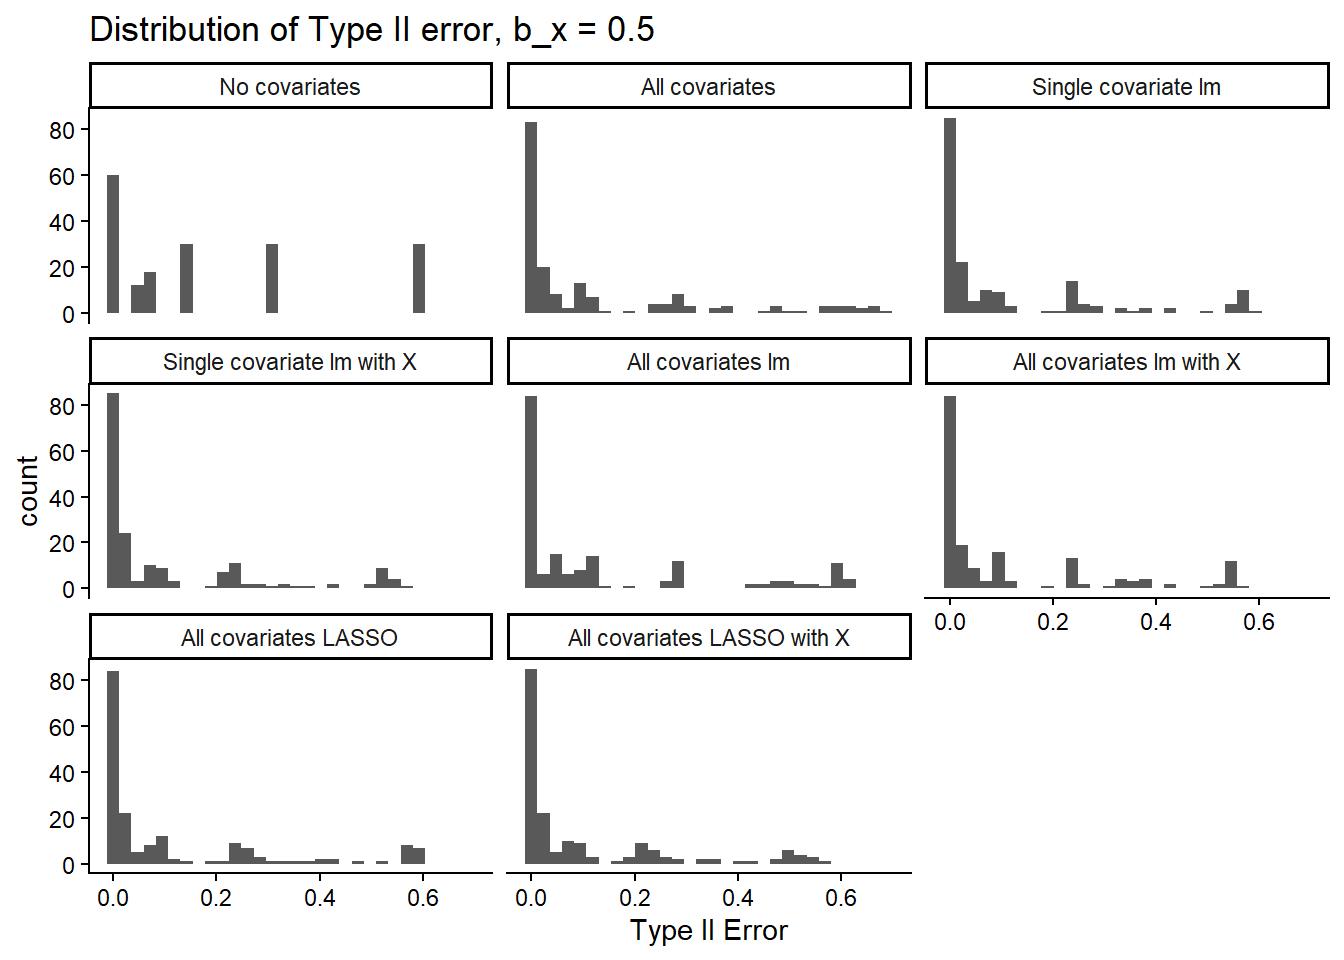

In [ ]:
#| label: fig-histograms-all-05

h05 |>
  filter(method != "p-hacking") |> 
  ggplot(aes(x = type_II)) +
  geom_histogram() +
  facet_wrap(~ method) +
  labs(x = "Type II Error",
       title = "Distribution of Type II error, b_x = 0.5")

In [ ]:
#| label: tbl-typeII-nobs-02

d_02 |> 
  filter(method != "p-hacking") |> 
  group_by(method, n_obs, n_covs, r_ycov, p_good_covs, r_cov) |> 
  summarise(prop_not_sig = mean(p_value >= 0.05),
            .groups = "drop") |> 
  group_by(n_obs, method) |> 
  summarise(typeII_min = min(prop_not_sig),
            typeII_max = max(prop_not_sig),
            typeII_mean = mean(prop_not_sig),
            .groups = "drop") |> 
  kbl(caption = "Type II error by n_obs, b_x = 0.2")

Warning in attr(x, "align"): 'xfun::attr()' is deprecated.
Use 'xfun::attr2()' instead.
See help("Deprecated")

    n_obs method                          typeII_min   typeII_max   typeII_mean
  ------- ----------------------------- ------------ ------------ -------------
       50 No covariates                        0.890        0.897         0.894
       50 All covariates                       0.821        0.911         0.875
       50 Single covariate lm                  0.808        0.893         0.862
       50 Single covariate lm with X           0.803        0.881         0.849
       50 All covariates lm                    0.857        0.899         0.884
       50 All covariates lm with X             0.784        0.880         0.840
       50 All covariates LASSO                 0.805        0.897         0.867
       50 All covariates LASSO with X          0.751        0.878         0.832
      100 No covariates                        0.828        0.836         0.832
      100 All covariates                       0.614        0.835         0.763
      100 Single covariate lm                  0.596        0.823         0.752
      100 Single covariate lm with X           0.594        0.817         0.746
      100 All covariates lm                    0.699        0.832         0.778
      100 All covariates lm with X             0.612        0.817         0.741
      100 All covariates LASSO                 0.602        0.824         0.758
      100 All covariates LASSO with X          0.577        0.815         0.737
      150 No covariates                        0.766        0.775         0.770
      150 All covariates                       0.428        0.760         0.657
      150 Single covariate lm                  0.414        0.759         0.647
      150 Single covariate lm with X           0.413        0.755         0.643
      150 All covariates lm                    0.521        0.763         0.670
      150 All covariates lm with X             0.443        0.755         0.642
      150 All covariates LASSO                 0.422        0.760         0.653
      150 All covariates LASSO with X          0.407        0.754         0.638
      200 No covariates                        0.704        0.716         0.709
      200 All covariates                       0.287        0.688         0.561
      200 Single covariate lm                  0.276        0.686         0.552
      200 Single covariate lm with X           0.275        0.684         0.549
      200 All covariates lm                    0.363        0.687         0.570
      200 All covariates lm with X             0.300        0.684         0.550
      200 All covariates LASSO                 0.284        0.687         0.557
      200 All covariates LASSO with X          0.275        0.682         0.546
      300 No covariates                        0.588        0.597         0.593
      300 All covariates                       0.116        0.565         0.404
      300 Single covariate lm                  0.111        0.562         0.397
      300 Single covariate lm with X           0.111        0.561         0.395
      300 All covariates lm                    0.143        0.562         0.409
      300 All covariates lm with X             0.123        0.561         0.397
      300 All covariates LASSO                 0.115        0.564         0.401
      300 All covariates LASSO with X          0.112        0.561         0.395
      400 No covariates                        0.481        0.491         0.487
      400 All covariates                       0.043        0.452         0.288
      400 Single covariate lm                  0.041        0.450         0.283
      400 Single covariate lm with X           0.041        0.449         0.282
      400 All covariates lm                    0.050        0.451         0.291
      400 All covariates lm with X             0.045        0.449         0.284
      400 All covariates LASSO                 0.043        0.452         0.286
      400 All covariates LASSO with X          0.041        0.449         0.282


In [ ]:
#| label: tbl-typeII-nobs-05

d_05 |> 
  filter(method != "p-hacking") |> 
  group_by(method, n_obs, n_covs, r_ycov, p_good_covs, r_cov) |> 
  summarise(prop_not_sig = mean(p_value >= 0.05),
            .groups = "drop") |> 
  group_by(n_obs, method) |> 
  summarise(typeII_min = min(prop_not_sig),
            typeII_max = max(prop_not_sig),
            typeII_mean = mean(prop_not_sig),
            .groups = "drop") |> 
  kbl(caption = "Type II error by n_obs, b_x = 0.5")

Warning in attr(x, "align"): 'xfun::attr()' is deprecated.
Use 'xfun::attr2()' instead.
See help("Deprecated")

    n_obs method                          typeII_min   typeII_max   typeII_mean
  ------- ----------------------------- ------------ ------------ -------------
       50 No covariates                        0.585        0.595         0.589
       50 All covariates                       0.274        0.687         0.503
       50 Single covariate lm                  0.227        0.581         0.446
       50 Single covariate lm with X           0.223        0.558         0.420
       50 All covariates lm                    0.423        0.608         0.542
       50 All covariates lm with X             0.318        0.558         0.454
       50 All covariates LASSO                 0.229        0.598         0.467
       50 All covariates LASSO with X          0.171        0.558         0.408
      100 No covariates                        0.296        0.308         0.303
      100 All covariates                       0.014        0.304         0.171
      100 Single covariate lm                  0.010        0.276         0.151
      100 Single covariate lm with X           0.010        0.268         0.146
      100 All covariates lm                    0.058        0.295         0.189
      100 All covariates lm with X             0.035        0.268         0.158
      100 All covariates LASSO                 0.012        0.285         0.159
      100 All covariates LASSO with X          0.009        0.270         0.144
      150 No covariates                        0.136        0.143         0.140
      150 All covariates                       0.000        0.119         0.056
      150 Single covariate lm                  0.000        0.115         0.050
      150 Single covariate lm with X           0.000        0.113         0.049
      150 All covariates lm                    0.003        0.121         0.063
      150 All covariates lm with X             0.002        0.113         0.054
      150 All covariates LASSO                 0.000        0.114         0.053
      150 All covariates LASSO with X          0.000        0.114         0.049
      200 No covariates                        0.056        0.062         0.059
      200 All covariates                       0.000        0.044         0.018
      200 Single covariate lm                  0.000        0.043         0.016
      200 Single covariate lm with X           0.000        0.042         0.016
      200 All covariates lm                    0.000        0.044         0.021
      200 All covariates lm with X             0.000        0.042         0.018
      200 All covariates LASSO                 0.000        0.044         0.017
      200 All covariates LASSO with X          0.000        0.043         0.016
      300 No covariates                        0.008        0.010         0.009
      300 All covariates                       0.000        0.006         0.002
      300 Single covariate lm                  0.000        0.005         0.001
      300 Single covariate lm with X           0.000        0.005         0.001
      300 All covariates lm                    0.000        0.005         0.002
      300 All covariates lm with X             0.000        0.005         0.002
      300 All covariates LASSO                 0.000        0.005         0.001
      300 All covariates LASSO with X          0.000        0.006         0.001
      400 No covariates                        0.001        0.002         0.001
      400 All covariates                       0.000        0.001         0.000
      400 Single covariate lm                  0.000        0.000         0.000
      400 Single covariate lm with X           0.000        0.000         0.000
      400 All covariates lm                    0.000        0.001         0.000
      400 All covariates lm with X             0.000        0.000         0.000
      400 All covariates LASSO                 0.000        0.001         0.000
      400 All covariates LASSO with X          0.000        0.000         0.000


In [ ]:
#| label: tbl-typeII-ncovs-02

d_02 |> 
  filter(method != "p-hacking") |> 
  group_by(method, n_obs, n_covs, r_ycov, p_good_covs, r_cov) |> 
  summarise(prop_not_sig = mean(p_value >= 0.05),
            .groups = "drop") |> 
  group_by(n_covs, method) |> 
  summarise(typeII_min = min(prop_not_sig),
            typeII_max = max(prop_not_sig),
            typeII_mean = mean(prop_not_sig),
            .groups = "drop") |> 
  kbl(caption = "Type II error by n_covs, b_x = 0.2")

Warning in attr(x, "align"): 'xfun::attr()' is deprecated.
Use 'xfun::attr2()' instead.
See help("Deprecated")

    n_covs method                          typeII_min   typeII_max   typeII_mean
  -------- ----------------------------- ------------ ------------ -------------
         4 No covariates                        0.482        0.896         0.714
         4 All covariates                       0.226        0.893         0.642
         4 Single covariate lm                  0.225        0.893         0.640
         4 Single covariate lm with X           0.225        0.881         0.637
         4 All covariates lm                    0.225        0.895         0.642
         4 All covariates lm with X             0.225        0.880         0.636
         4 All covariates LASSO                 0.225        0.893         0.642
         4 All covariates LASSO with X          0.225        0.878         0.637
         8 No covariates                        0.485        0.897         0.714
         8 All covariates                       0.125        0.895         0.604
         8 Single covariate lm                  0.124        0.890         0.598
         8 Single covariate lm with X           0.124        0.872         0.594
         8 All covariates lm                    0.124        0.893         0.606
         8 All covariates lm with X             0.124        0.870         0.591
         8 All covariates LASSO                 0.125        0.893         0.602
         8 All covariates LASSO with X          0.124        0.868         0.592
        12 No covariates                        0.481        0.895         0.714
        12 All covariates                       0.080        0.900         0.582
        12 Single covariate lm                  0.078        0.890         0.573
        12 Single covariate lm with X           0.078        0.869         0.568
        12 All covariates lm                    0.080        0.895         0.590
        12 All covariates lm with X             0.079        0.865         0.565
        12 All covariates LASSO                 0.080        0.893         0.578
        12 All covariates LASSO with X          0.079        0.859         0.562
        16 No covariates                        0.484        0.897         0.714
        16 All covariates                       0.057        0.904         0.569
        16 Single covariate lm                  0.055        0.892         0.556
        16 Single covariate lm with X           0.055        0.872         0.550
        16 All covariates lm                    0.058        0.899         0.583
        16 All covariates lm with X             0.056        0.864         0.548
        16 All covariates LASSO                 0.056        0.897         0.562
        16 All covariates LASSO with X          0.055        0.852         0.541
        20 No covariates                        0.483        0.896         0.714
        20 All covariates                       0.043        0.911         0.561
        20 Single covariate lm                  0.041        0.890         0.544
        20 Single covariate lm with X           0.041        0.877         0.538
        20 All covariates lm                    0.050        0.898         0.580
        20 All covariates lm with X             0.045        0.863         0.539
        20 All covariates LASSO                 0.043        0.896         0.551
        20 All covariates LASSO with X          0.041        0.844         0.525


In [ ]:
#| label: tbl-typeII-ncovs-05

d_05 |> 
  filter(method != "p-hacking") |> 
  group_by(method, n_obs, n_covs, r_ycov, p_good_covs, r_cov) |> 
  summarise(prop_not_sig = mean(p_value >= 0.05),
            .groups = "drop") |> 
  group_by(n_covs, method) |> 
  summarise(typeII_min = min(prop_not_sig),
            typeII_max = max(prop_not_sig),
            typeII_mean = mean(prop_not_sig),
            .groups = "drop") |> 
  kbl(caption = "Type II error by n_covs, b_x = 0.5")

Warning in attr(x, "align"): 'xfun::attr()' is deprecated.
Use 'xfun::attr2()' instead.
See help("Deprecated")

    n_covs method                          typeII_min   typeII_max   typeII_mean
  -------- ----------------------------- ------------ ------------ -------------
         4 No covariates                        0.001        0.595         0.184
         4 All covariates                       0.000        0.589         0.134
         4 Single covariate lm                  0.000        0.581         0.132
         4 Single covariate lm with X           0.000        0.558         0.128
         4 All covariates lm                    0.000        0.587         0.137
         4 All covariates lm with X             0.000        0.558         0.129
         4 All covariates LASSO                 0.000        0.588         0.134
         4 All covariates LASSO with X          0.000        0.558         0.129
         8 No covariates                        0.001        0.593         0.183
         8 All covariates                       0.000        0.605         0.121
         8 Single covariate lm                  0.000        0.578         0.114
         8 Single covariate lm with X           0.000        0.539         0.109
         8 All covariates lm                    0.000        0.591         0.130
         8 All covariates lm with X             0.000        0.546         0.114
         8 All covariates LASSO                 0.000        0.588         0.119
         8 All covariates LASSO with X          0.000        0.540         0.109
        12 No covariates                        0.001        0.594         0.184
        12 All covariates                       0.000        0.624         0.119
        12 Single covariate lm                  0.000        0.569         0.106
        12 Single covariate lm with X           0.000        0.520         0.100
        12 All covariates lm                    0.000        0.605         0.134
        12 All covariates lm with X             0.000        0.538         0.110
        12 All covariates LASSO                 0.000        0.593         0.113
        12 All covariates LASSO with X          0.000        0.518         0.099
        16 No covariates                        0.001        0.593         0.184
        16 All covariates                       0.000        0.656         0.122
        16 Single covariate lm                  0.000        0.576         0.102
        16 Single covariate lm with X           0.000        0.525         0.096
        16 All covariates lm                    0.000        0.605         0.137
        16 All covariates lm with X             0.000        0.538         0.109
        16 All covariates LASSO                 0.000        0.597         0.109
        16 All covariates LASSO with X          0.000        0.513         0.092
        20 No covariates                        0.001        0.591         0.183
        20 All covariates                       0.000        0.687         0.128
        20 Single covariate lm                  0.000        0.575         0.100
        20 Single covariate lm with X           0.000        0.536         0.094
        20 All covariates lm                    0.000        0.608         0.142
        20 All covariates lm with X             0.000        0.541         0.111
        20 All covariates LASSO                 0.000        0.598         0.107
        20 All covariates LASSO with X          0.000        0.500         0.087


In [ ]:
#| label: tbl-typeII-pgoodcovs-02

d_02 |> 
  filter(method != "p-hacking") |> 
  group_by(method, n_obs, n_covs, r_ycov, p_good_covs, r_cov) |> 
  summarise(prop_not_sig = mean(p_value >= 0.05),
            .groups = "drop") |> 
  group_by(p_good_covs, method) |> 
  summarise(typeII_min = min(prop_not_sig),
            typeII_max = max(prop_not_sig),
            typeII_mean = mean(prop_not_sig),
            .groups = "drop") |> 
  kbl(caption = "Type II error by p_good_covs, b_x = 0.2")

Warning in attr(x, "align"): 'xfun::attr()' is deprecated.
Use 'xfun::attr2()' instead.
See help("Deprecated")

    p_good_covs method                          typeII_min   typeII_max   typeII_mean
  ------------- ----------------------------- ------------ ------------ -------------
           0.25 No covariates                        0.485        0.897         0.714
           0.25 All covariates                       0.156        0.911         0.632
           0.25 Single covariate lm                  0.147        0.892         0.620
           0.25 Single covariate lm with X           0.145        0.881         0.613
           0.25 All covariates lm                    0.147        0.899         0.626
           0.25 All covariates lm with X             0.143        0.880         0.610
           0.25 All covariates LASSO                 0.151        0.897         0.626
           0.25 All covariates LASSO with X          0.144        0.878         0.607
           0.50 No covariates                        0.481        0.896         0.714
           0.50 All covariates                       0.073        0.907         0.585
           0.50 Single covariate lm                  0.068        0.893         0.576
           0.50 Single covariate lm with X           0.068        0.880         0.571
           0.50 All covariates lm                    0.071        0.898         0.593
           0.50 All covariates lm with X             0.068        0.878         0.569
           0.50 All covariates LASSO                 0.072        0.894         0.581
           0.50 All covariates LASSO with X          0.069        0.878         0.565
           0.75 No covariates                        0.483        0.896         0.714
           0.75 All covariates                       0.043        0.908         0.557
           0.75 Single covariate lm                  0.041        0.890         0.551
           0.75 Single covariate lm with X           0.041        0.877         0.549
           0.75 All covariates lm                    0.050        0.898         0.581
           0.75 All covariates lm with X             0.045        0.873         0.548
           0.75 All covariates LASSO                 0.043        0.891         0.553
           0.75 All covariates LASSO with X          0.041        0.876         0.542


In [ ]:
#| label: tbl-typeII-pgoodcovs-05

d_05 |> 
  filter(method != "p-hacking") |> 
  group_by(method, n_obs, n_covs, r_ycov, p_good_covs, r_cov) |> 
  summarise(prop_not_sig = mean(p_value >= 0.05),
            .groups = "drop") |> 
  group_by(p_good_covs, method) |> 
  summarise(typeII_min = min(prop_not_sig),
            typeII_max = max(prop_not_sig),
            typeII_mean = mean(prop_not_sig),
            .groups = "drop") |> 
  kbl(caption = "Type II error by p_good_covs, b_x = 0.5")

Warning in attr(x, "align"): 'xfun::attr()' is deprecated.
Use 'xfun::attr2()' instead.
See help("Deprecated")

    p_good_covs method                          typeII_min   typeII_max   typeII_mean
  ------------- ----------------------------- ------------ ------------ -------------
           0.25 No covariates                        0.001        0.593         0.184
           0.25 All covariates                       0.000        0.687         0.144
           0.25 Single covariate lm                  0.000        0.581         0.125
           0.25 Single covariate lm with X           0.000        0.558         0.117
           0.25 All covariates lm                    0.000        0.608         0.139
           0.25 All covariates lm with X             0.000        0.558         0.123
           0.25 All covariates LASSO                 0.000        0.598         0.133
           0.25 All covariates LASSO with X          0.000        0.558         0.117
           0.50 No covariates                        0.001        0.591         0.184
           0.50 All covariates                       0.000        0.674         0.121
           0.50 Single covariate lm                  0.000        0.570         0.107
           0.50 Single covariate lm with X           0.000        0.542         0.102
           0.50 All covariates lm                    0.000        0.607         0.134
           0.50 All covariates lm with X             0.000        0.546         0.112
           0.50 All covariates LASSO                 0.000        0.588         0.114
           0.50 All covariates LASSO with X          0.000        0.542         0.100
           0.75 No covariates                        0.001        0.595         0.184
           0.75 All covariates                       0.000        0.666         0.110
           0.75 Single covariate lm                  0.000        0.567         0.100
           0.75 Single covariate lm with X           0.000        0.537         0.097
           0.75 All covariates lm                    0.000        0.598         0.135
           0.75 All covariates lm with X             0.000        0.546         0.109
           0.75 All covariates LASSO                 0.000        0.569         0.102
           0.75 All covariates LASSO with X          0.000        0.540         0.092


In [ ]:
#| label: tbl-typeII-rycov-02

d_02 |> 
  filter(method != "p-hacking") |> 
  group_by(method, n_obs, n_covs, r_ycov, p_good_covs, r_cov) |> 
  summarise(prop_not_sig = mean(p_value >= 0.05),
            .groups = "drop") |> 
  group_by(r_ycov, method) |> 
  summarise(typeII_min = min(prop_not_sig),
            typeII_max = max(prop_not_sig),
            typeII_mean = mean(prop_not_sig),
            .groups = "drop") |> 
  kbl(caption = "Type II error by correlations, b_x = 0.2")

Warning in attr(x, "align"): 'xfun::attr()' is deprecated.
Use 'xfun::attr2()' instead.
See help("Deprecated")

    r_ycov method                          typeII_min   typeII_max   typeII_mean
  -------- ----------------------------- ------------ ------------ -------------
       0.3 No covariates                        0.481        0.897         0.714
       0.3 All covariates                       0.380        0.911         0.678
       0.3 Single covariate lm                  0.376        0.893         0.671
       0.3 Single covariate lm with X           0.374        0.881         0.664
       0.3 All covariates lm                    0.403        0.899         0.685
       0.3 All covariates lm with X             0.384        0.880         0.662
       0.3 All covariates LASSO                 0.374        0.897         0.673
       0.3 All covariates LASSO with X          0.368        0.878         0.658
       0.5 No covariates                        0.482        0.897         0.714
       0.5 All covariates                       0.043        0.881         0.505
       0.5 Single covariate lm                  0.041        0.880         0.494
       0.5 Single covariate lm with X           0.041        0.874         0.491
       0.5 All covariates lm                    0.050        0.887         0.516
       0.5 All covariates lm with X             0.045        0.872         0.489
       0.5 All covariates LASSO                 0.043        0.882         0.501
       0.5 All covariates LASSO with X          0.041        0.869         0.486


In [ ]:
#| label: tbl-typeII-rycov-05

d_05 |> 
  filter(method != "p-hacking") |> 
  group_by(method, n_obs, n_covs, r_ycov, p_good_covs, r_cov) |> 
  summarise(prop_not_sig = mean(p_value >= 0.05),
            .groups = "drop") |> 
  group_by(r_ycov, method) |> 
  summarise(typeII_min = min(prop_not_sig),
            typeII_max = max(prop_not_sig),
            typeII_mean = mean(prop_not_sig),
            .groups = "drop") |> 
  kbl(caption = "Type II error by correlations, b_x = 0.5")

Warning in attr(x, "align"): 'xfun::attr()' is deprecated.
Use 'xfun::attr2()' instead.
See help("Deprecated")

    r_ycov method                          typeII_min   typeII_max   typeII_mean
  -------- ----------------------------- ------------ ------------ -------------
       0.3 No covariates                        0.001        0.595         0.184
       0.3 All covariates                       0.000        0.687         0.170
       0.3 Single covariate lm                  0.000        0.581         0.154
       0.3 Single covariate lm with X           0.000        0.558         0.146
       0.3 All covariates lm                    0.000        0.608         0.172
       0.3 All covariates lm with X             0.000        0.558         0.153
       0.3 All covariates LASSO                 0.000        0.598         0.159
       0.3 All covariates LASSO with X          0.000        0.558         0.142
       0.5 No covariates                        0.001        0.594         0.184
       0.5 All covariates                       0.000        0.516         0.080
       0.5 Single covariate lm                  0.000        0.499         0.067
       0.5 Single covariate lm with X           0.000        0.488         0.065
       0.5 All covariates lm                    0.000        0.563         0.100
       0.5 All covariates lm with X             0.000        0.486         0.076
       0.5 All covariates LASSO                 0.000        0.516         0.074
       0.5 All covariates LASSO with X          0.000        0.487         0.064


### Parameter Estimates

In [ ]:
est_d_0 <- d_0 |> 
  ggplot(aes(x = estimate, color = method, linetype = method)) +
  geom_density(alpha = 0.5) +
  geom_vline(xintercept = 0, linetype = "dotted", color = "black") +
  scale_x_continuous(limits = c(-0.5, 0.5), breaks = seq(-0.5, 0.5, by = 0.5)) +
  labs(y = "Density",
       x = "Estimate") +
  scale_linetype_manual(values = method_linetypes) +
  scale_color_manual(values = method_colors) 

est_d_02 <- d_02 |> 
  filter(method != "p-hacking") |> 
  ggplot(aes(x = estimate, color = method, linetype = method)) +
  geom_density(alpha = 0.5) +
  geom_vline(xintercept = 0.2, linetype = "dotted") +
  scale_x_continuous(limits = c(-0.2, 0.8), breaks = c(0, 0.2, 0.6)) +
  labs(y = "Density",
       x = "Estimate") +
  scale_linetype_manual(values = method_linetypes) +
  scale_color_manual(values = method_colors) +
  theme(legend.position = "none")

est_d_05 <- d_05 |> 
  filter(method != "p-hacking") |> 
  ggplot(aes(x = estimate, color = method, linetype = method)) +
  geom_density(alpha = 0.5) +
  geom_vline(xintercept = 0.5, linetype = "dotted") +
  scale_x_continuous(limits = c(0, 1), breaks = c(0, 0.5, 1)) +
  labs(y = "Density",
       x = "Estimate") + 
  scale_linetype_manual(values = method_linetypes) +
  scale_color_manual(values = method_colors) +
  theme(legend.position = "none")

(`stat_density()`).

(`stat_density()`).

(`stat_density()`).

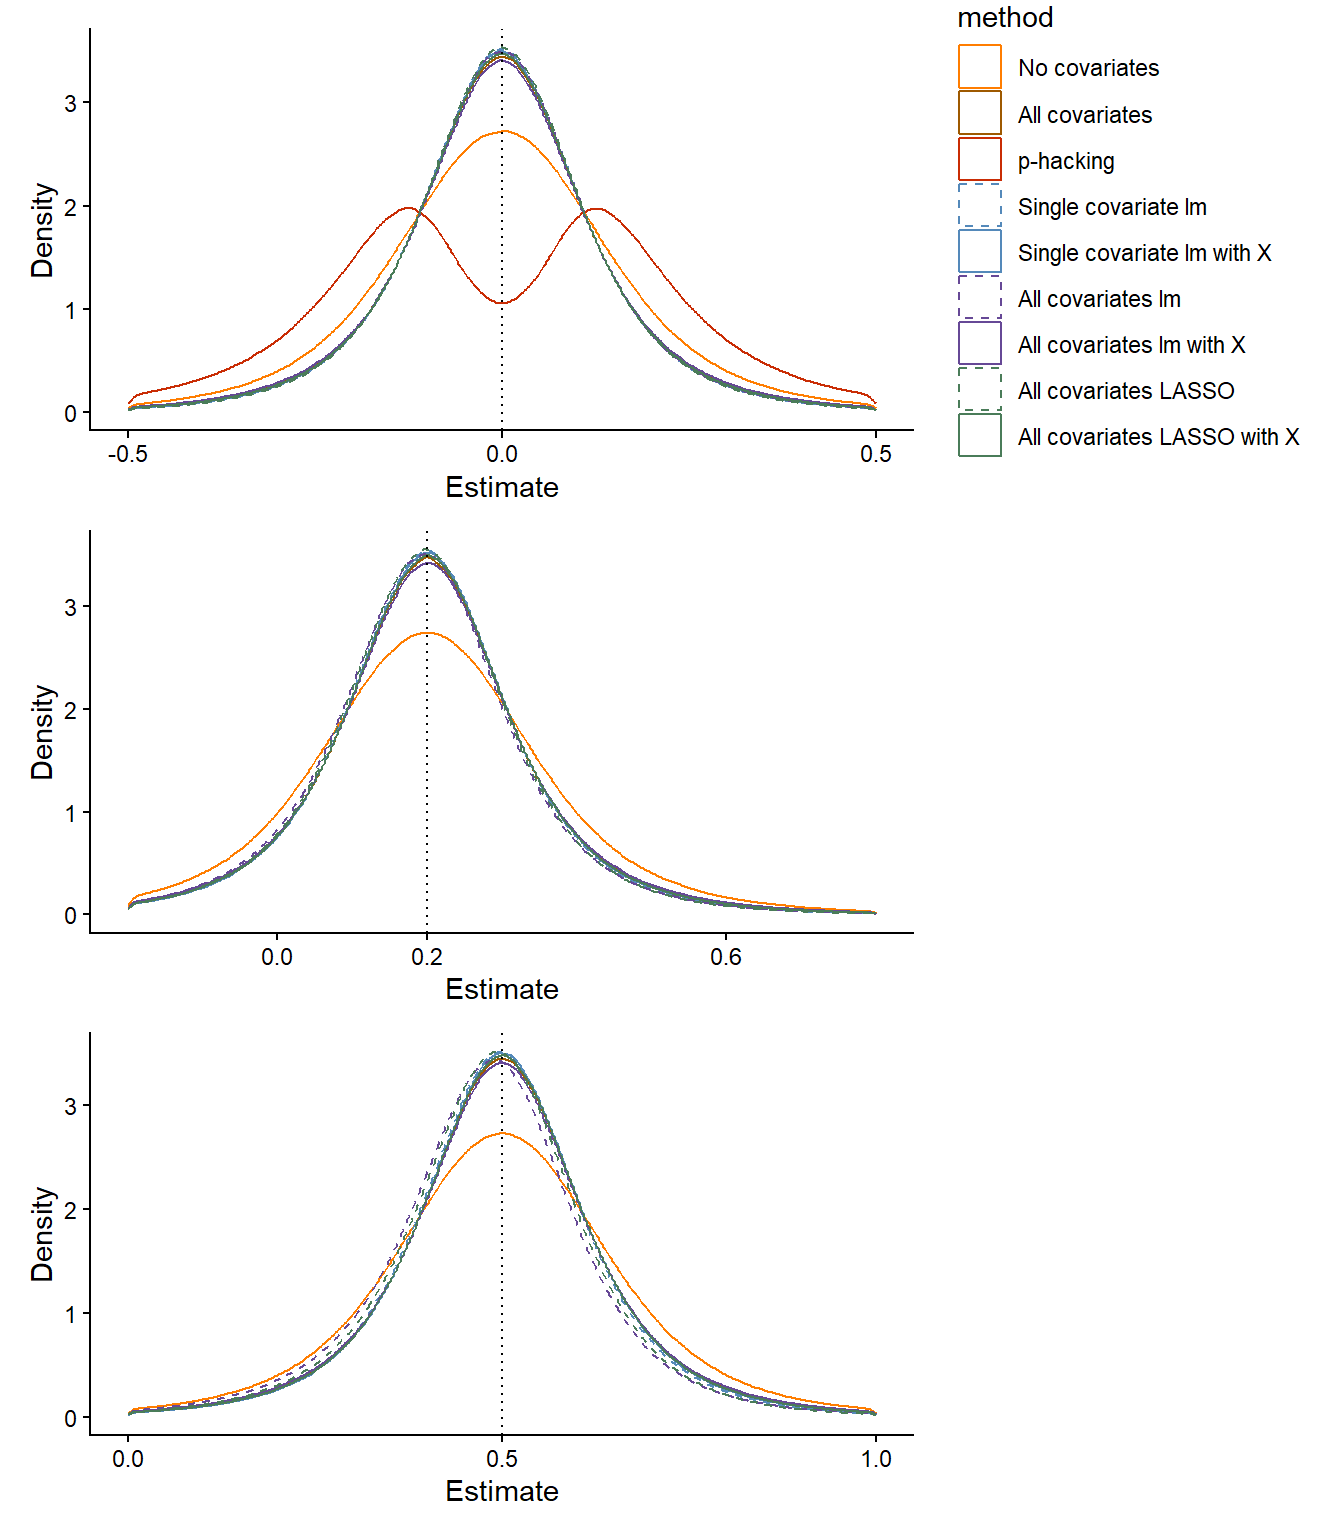

In [ ]:
#| label: fig-distribution-bx
#| fig-cap: "Sampling Distribution for Population Parameter Estimates."
#| fig-height: 8

est_d_0 / est_d_02 / est_d_05 